In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [11]:
import os, sys


def get_dir_n_levels_up(path, n):
    # Go up n levels from the given path
    for _ in range(n):
        path = os.path.dirname(path)
    return path


proj_root = get_dir_n_levels_up(os.path.abspath("__file__"), 3)
sys.path.append(proj_root)

print(proj_root)

d:\Work\repos\RL\unknown_graph_networks


In [12]:
import numpy as np
from rl_envs_forge.envs.network_graph.network_graph import NetworkGraph

from opinion_dynamics.utils.env_setup import EnvironmentFactory



In [13]:
import contextlib
import matplotlib.pyplot as plt


@contextlib.contextmanager
def intercept_show(pre_show=None):
    original_show = plt.show

    def wrapped_show(*args, **kwargs):
        if pre_show is not None:
            pre_show()
        return original_show(*args, **kwargs)

    plt.show = wrapped_show
    try:
        yield
    finally:
        plt.show = original_show


def _apply_font_scale(
    *,
    title_size=18,
    label_size=14,
    tick_size=12,
    legend_size=12,
    annotate_size=12,
):
    """
    Increase title/labels/ticks/legend/annotations on the current figure.
    Works for seaborn plots + networkx plots (labels are Text objects).
    """
    fig = plt.gcf()

    # Update all axes (handles subplots too)
    for ax in fig.get_axes():
        # Title + axis labels
        ax.title.set_fontsize(title_size)
        ax.xaxis.label.set_fontsize(label_size)
        ax.yaxis.label.set_fontsize(label_size)

        # Tick labels
        ax.tick_params(axis="both", which="major", labelsize=tick_size)

        # Legends
        leg = ax.get_legend()
        if leg is not None:
            for t in leg.get_texts():
                t.set_fontsize(legend_size)
            if leg.get_title() is not None:
                leg.get_title().set_fontsize(legend_size)

        # Any other text artists inside axes (networkx node labels, annotations, etc.)
        for t in ax.texts:
            # Avoid shrinking labels you already made bigger elsewhere; just set.
            t.set_fontsize(annotate_size)


def _apply_bw_style(grid: bool = False, grid_axis: str = "y"):
    fig = plt.gcf()
    ax = plt.gca()

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.set_axisbelow(True)
    if grid:
        ax.grid(
            True,
            axis=grid_axis,
            which="major",
            color="black",
            alpha=0.25,
            linewidth=0.8,
            linestyle="-",
        )
    else:
        ax.grid(False)

    for spine in ax.spines.values():
        spine.set_color("black")
    ax.tick_params(colors="black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")
    ax.title.set_color("black")

    for line in ax.get_lines():
        line.set_color("black")

    for p in ax.patches:
        try:
            p.set_facecolor("white")
            p.set_edgecolor("black")
            p.set_linewidth(1.0)
        except Exception:
            pass

    for c in ax.collections:
        try:
            c.set_edgecolor("black")
        except Exception:
            pass
        try:
            c.set_color("black")
        except Exception:
            pass
        try:
            fc = c.get_facecolor()
            if fc is not None and len(fc) > 0:
                c.set_facecolor("white")
        except Exception:
            pass

    for p in ax.patches:
        try:
            p.set_edgecolor("black")
            p.set_facecolor("black")
        except Exception:
            pass


def render_styled(
    env,
    mode="centralities",
    *,
    theme="bw",
    grid=False,
    # NEW: font sizes
    title_size=18,
    label_size=14,
    tick_size=12,
    legend_size=12,
    annotate_size=12,
    **render_kwargs,
):
    def pre_show():
        if theme == "bw":
            _apply_bw_style(grid=grid)
        _apply_font_scale(
            title_size=title_size,
            label_size=label_size,
            tick_size=tick_size,
            legend_size=legend_size,
            annotate_size=annotate_size,
        )

    with intercept_show(pre_show=pre_show):
        return env.render(mode=mode, **render_kwargs)

c:\Users\Chainsword\anaconda3\envs\phd_rl_algos\Lib\site-packages\rl_envs_forge\envs\network_graph\visualize.py:474: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_labels, y=sorted_centralities, palette="Blues_d")


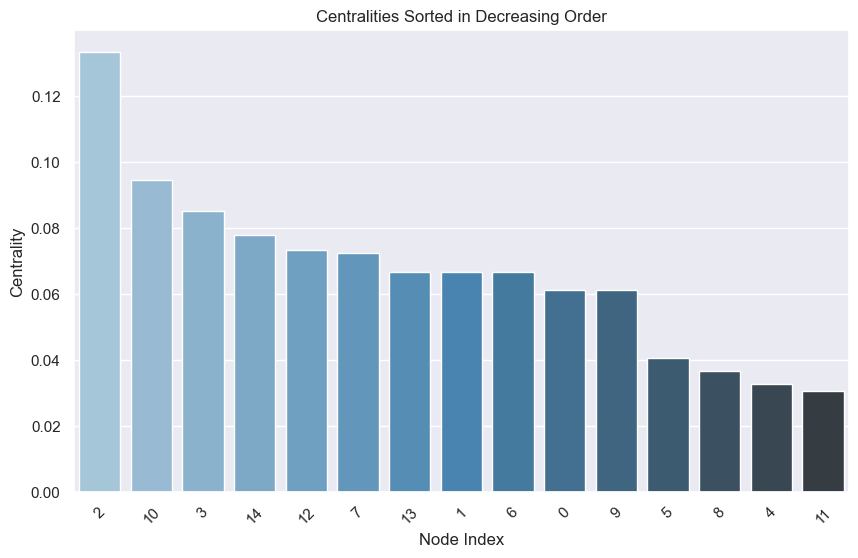

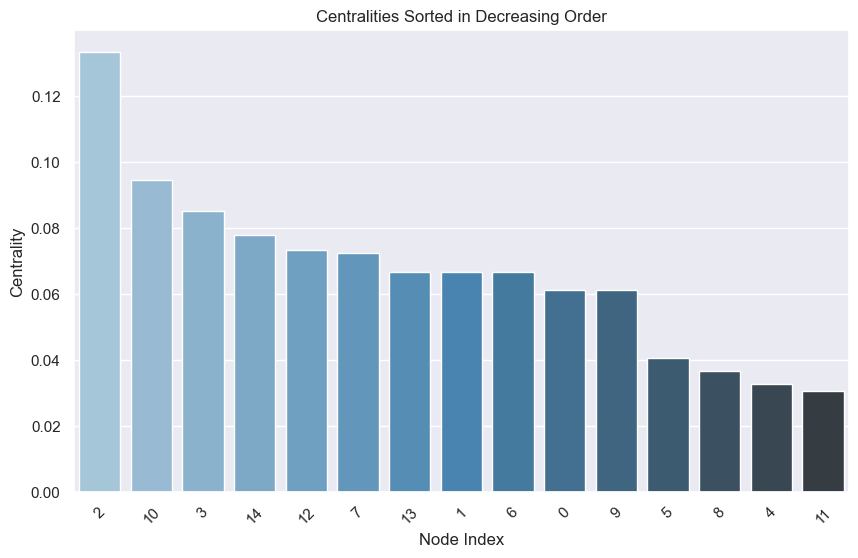

In [14]:
env_factory = EnvironmentFactory()
env = env_factory.get_randomized_env()
env.render(mode="centralities")

c:\Users\Chainsword\anaconda3\envs\phd_rl_algos\Lib\site-packages\rl_envs_forge\envs\network_graph\visualize.py:474: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_labels, y=sorted_centralities, palette="Blues_d")


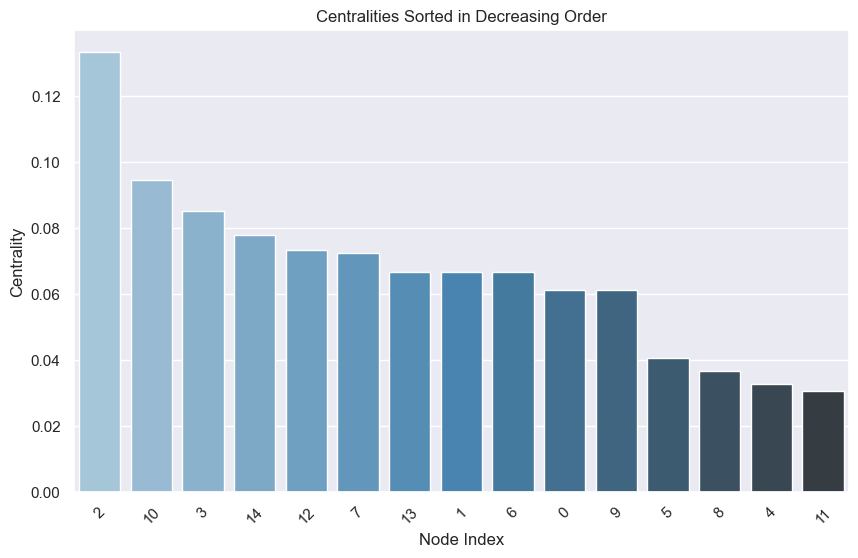

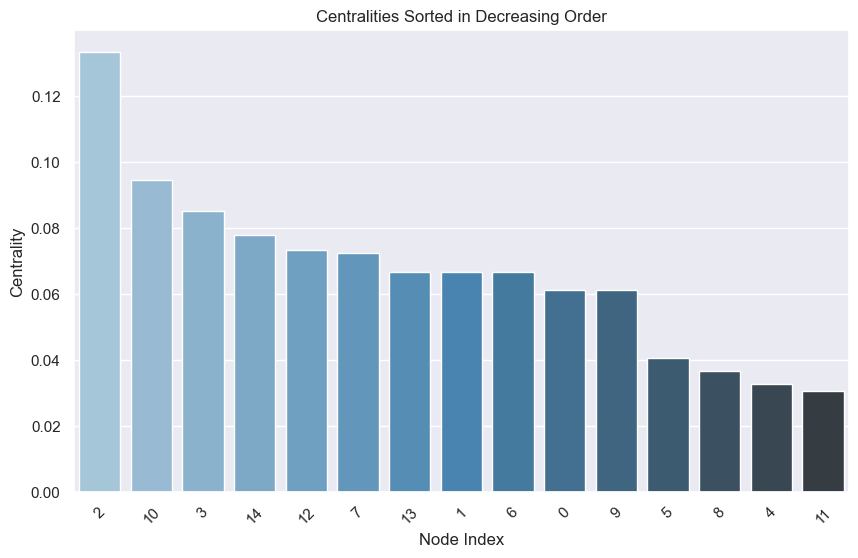

In [15]:
initial_opinions = np.linspace(0.01, 0.99, 15)

env = NetworkGraph(
    num_agents=15,
    initial_opinions=initial_opinions,
    # --- Paper-like graph generation (Barabási–Albert + directed pruning + QSC filter) ---
    graph_model="barabasi_albert",  # (alias: "albert_barabasi")
    ba_m=2,  # paper: AP=2
    ba_prune_max_frac=0.5,  # paper: prune randomly up to half the edges
    ba_qsc_tol=1e-8,  # eigenvalue tolerance for the "single 0 eig" check
    ba_max_tries=500,  # more tries reduces chance of fallback warning
    max_u=0.2,
    budget=1000.0,
    desired_opinion=1,
    t_campaign=2,
    t_s=0.5,
    max_steps=3000,
    opinion_end_tolerance=0.05,
    control_beta=0.4,
    normalize_reward=True,
    terminal_reward=0.5,
    seed=2,
    terminate_when_converged=True,
    dynamics_model="laplacian",  # or "coca"
)
env.reset()
env.render(mode="centralities")

c:\Users\Chainsword\anaconda3\envs\phd_rl_algos\Lib\site-packages\rl_envs_forge\envs\network_graph\visualize.py:474: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_labels, y=sorted_centralities, palette="Blues_d")


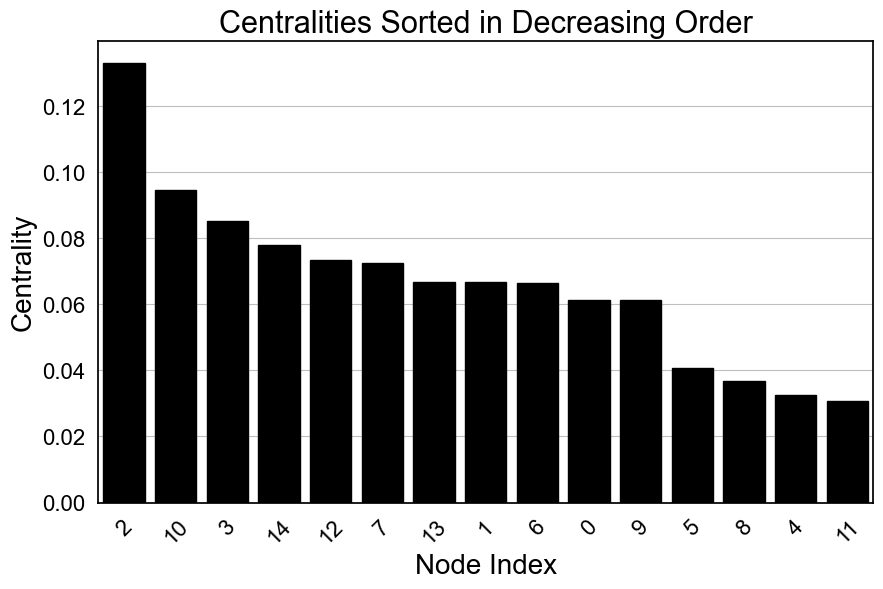

Exception: 

In [16]:
fig = render_styled(
    env,
    mode="centralities",
    theme="bw",
    grid=True,
    title_size=22,
    label_size=20,
    tick_size=16,
    annotate_size=20,
)
raise Exception

In [ ]:
fig.savefig("network_centrality_seed_42.pdf", bbox_inches="tight", pad_inches=0.01)

c:\Users\Chainsword\anaconda3\envs\phd_rl_algos\Lib\site-packages\rl_envs_forge\envs\network_graph\visualize.py:289: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_labels, y=sorted_centralities, palette="Blues_d")


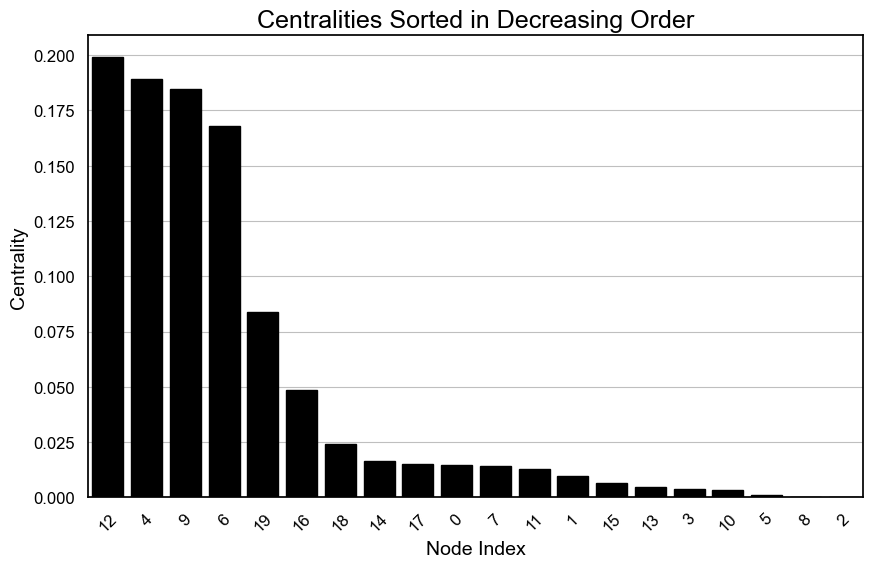

In [ ]:
# render_styled(env, mode="centralities", theme="bw", grid=True)

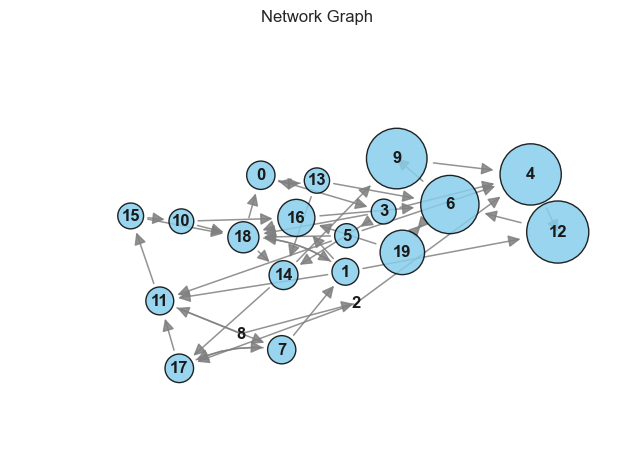

In [ ]:
env.render(mode="matplotlib")

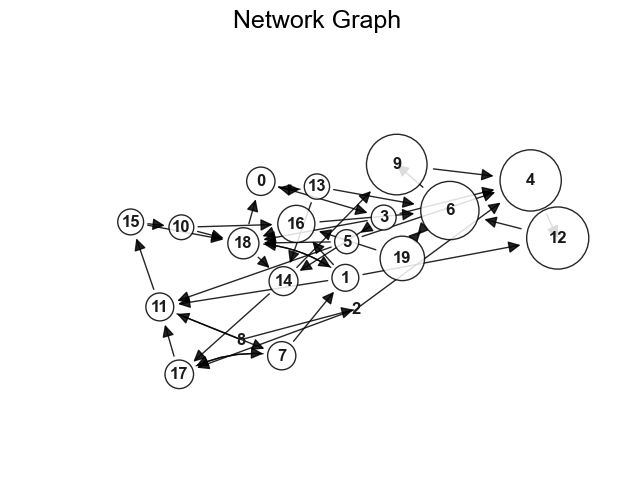

In [ ]:
render_styled(env, mode="matplotlib", theme="bw", grid=False)

In [ ]:
env.centralities

array([0.01453041, 0.00958603, 0.        , 0.0036326 , 0.18934941,
       0.00121087, 0.16815923, 0.01412679, 0.        , 0.18450594,
       0.00325421, 0.01301683, 0.19893545, 0.00484347, 0.01634671,
       0.00650841, 0.04845993, 0.01523675, 0.02421735, 0.08407961])